In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload
#AN ALGORITHMS THANKS TO MINEL AND KAITLYN @NAUMANN-LAB GITHUB
import numpy as np
import pandas as pd
import tifffile
import SimpleITK as sitk
import sys, os, re
from scipy.ndimage import gaussian_filter

sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import matplotlib.pyplot as plt
from registration import sitkalignment
from registration import registration_utils as utils
from scipy.ndimage import rotate

plt.rcParams.update({'font.size': 13})

cv2 not available


__STEP0: LOAD MAPZBRAIN ATLAS + MY FISH__

In [3]:
#Load MAPZBrain Atlas in tif
template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"
template = tifffile.imread(template_path)
imgsize = 1024
downsample = 1
gaussian_sigma = 1
template_new = np.full([template.shape[0], imgsize, imgsize], np.nan)#interpolate the template to a bigger size
for z in range(template.shape[0]):
    template_new[z]= gaussian_filter(sitkalignment.embed_image(template[z, :, :], imgsize), sigma=gaussian_sigma)#gaussian smooze the template
template_new = template_new[:, ::downsample, ::downsample]


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Zichen\AppData\Local\Temp\ipykernel_16852\4119662289.py:2: SyntaxWarning: invalid escape sequence '\D'
  template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"


looking at C:\Data\Imaging\251021_dotsweep\fish5_overlap//Imaging//plane_0


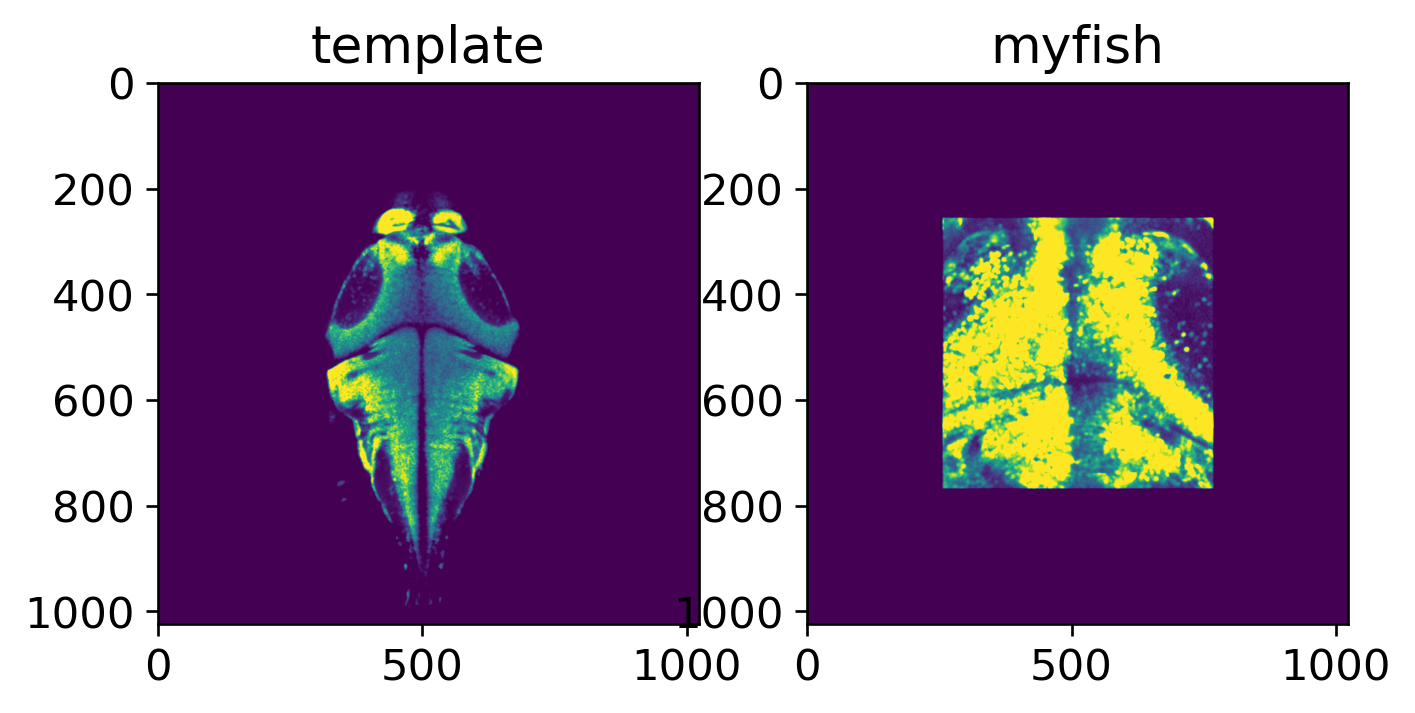

Error: [WinError 183] Cannot create a file when that file already exists: 'C:\\Data\\Imaging\\251021_dotsweep\\fish5_overlap//Imaging//plane_0//Alignment//'
looking at C:\Data\Imaging\251021_dotsweep\fish5_overlap//Imaging//plane_1


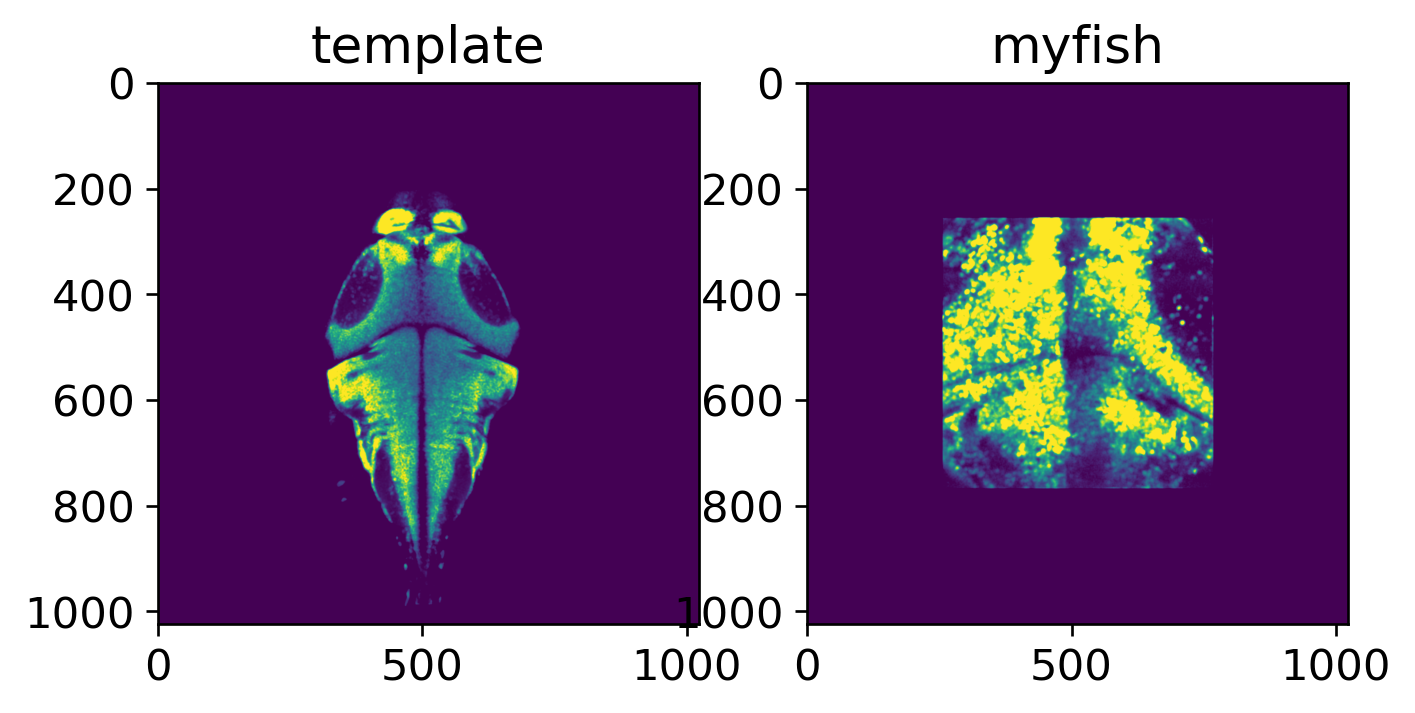

Error: [WinError 183] Cannot create a file when that file already exists: 'C:\\Data\\Imaging\\251021_dotsweep\\fish5_overlap//Imaging//plane_1//Alignment//'
looking at C:\Data\Imaging\251021_dotsweep\fish5_overlap//Imaging//plane_2


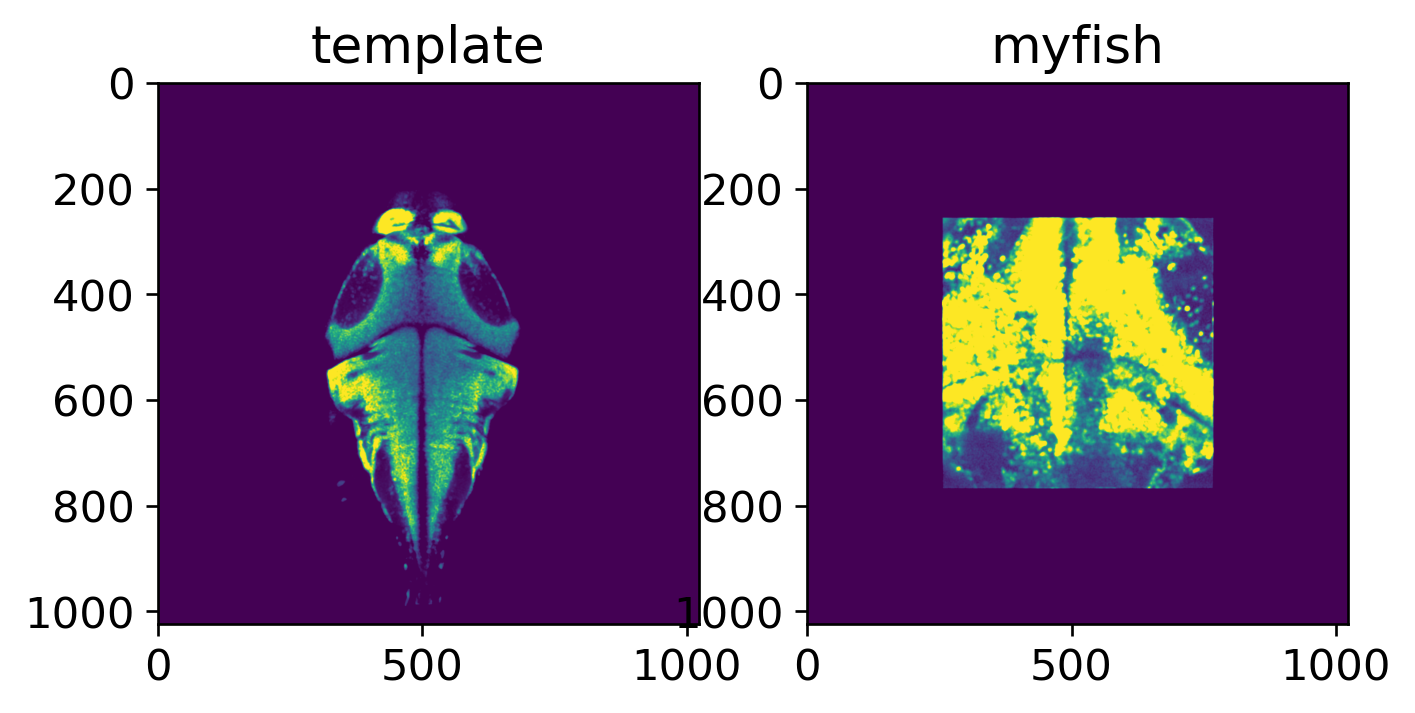

Error: [WinError 183] Cannot create a file when that file already exists: 'C:\\Data\\Imaging\\251021_dotsweep\\fish5_overlap//Imaging//plane_2//Alignment//'


In [37]:
#Load my fish from suite2p result
#Examine if the min/max parameter looks correct
vmin =100
vmax =500
vmax_template = 200
vmin_template = 20
rot = 0
myfish_path = r"C:\Data\Imaging\251021_dotsweep\fish5_overlap" + '//Imaging//'
imgs = []
#get all the plane paths
plane_paths = []
for entry in os.listdir(myfish_path):
    if os.path.isdir(os.path.join(myfish_path, entry)) and 'plane_' in str(entry):
        plane_paths.append(os.path.join(myfish_path, entry))
for plane_path in plane_paths:
    print(f'looking at {plane_path}')
    ops = np.load(plane_path + '//ops.npy', allow_pickle=True)
    img = ops.item()['refImg'][:, ::-1]
    img = np.rot90(np.flipud(img), k = -1)
    img = rotate(img, rot, reshape = False)
    img = np.divide(img, img.max())#enhance the image
    img *= 2**12

    img = sitkalignment.embed_image(img, imgsize)#interpolate the image to a bigger size
    img = gaussian_filter(img, sigma=gaussian_sigma)#gaussian smooze the image
    img = img[::downsample, ::downsample]
    img = np.clip(img, vmin, vmax)
    imgs.append(img)

    #plot bot the templates and the real image
    fig, ax = plt.subplots(1, 2, dpi = 240)
    ax[0].imshow(template_new[250], vmin = vmin_template, vmax = vmax_template)# show a random template plane
    ax[0].set_title('template')
    ax[1].imshow(img, vmin = vmin, vmax = vmax)
    ax[1].set_title('myfish')
    plt.show()
    plt.close()
    #make an output folder
    try:
        os.mkdir(plane_path + '//Alignment//')
    except OSError as e:
        print("Error:", e)

__STEP1A: PRELIMINARILY, FIND THE Z ATLAS PLANE THA ALIGNS. FIND THE GOOD CUTOFF FOR THE ROI THAT ALIGNS__

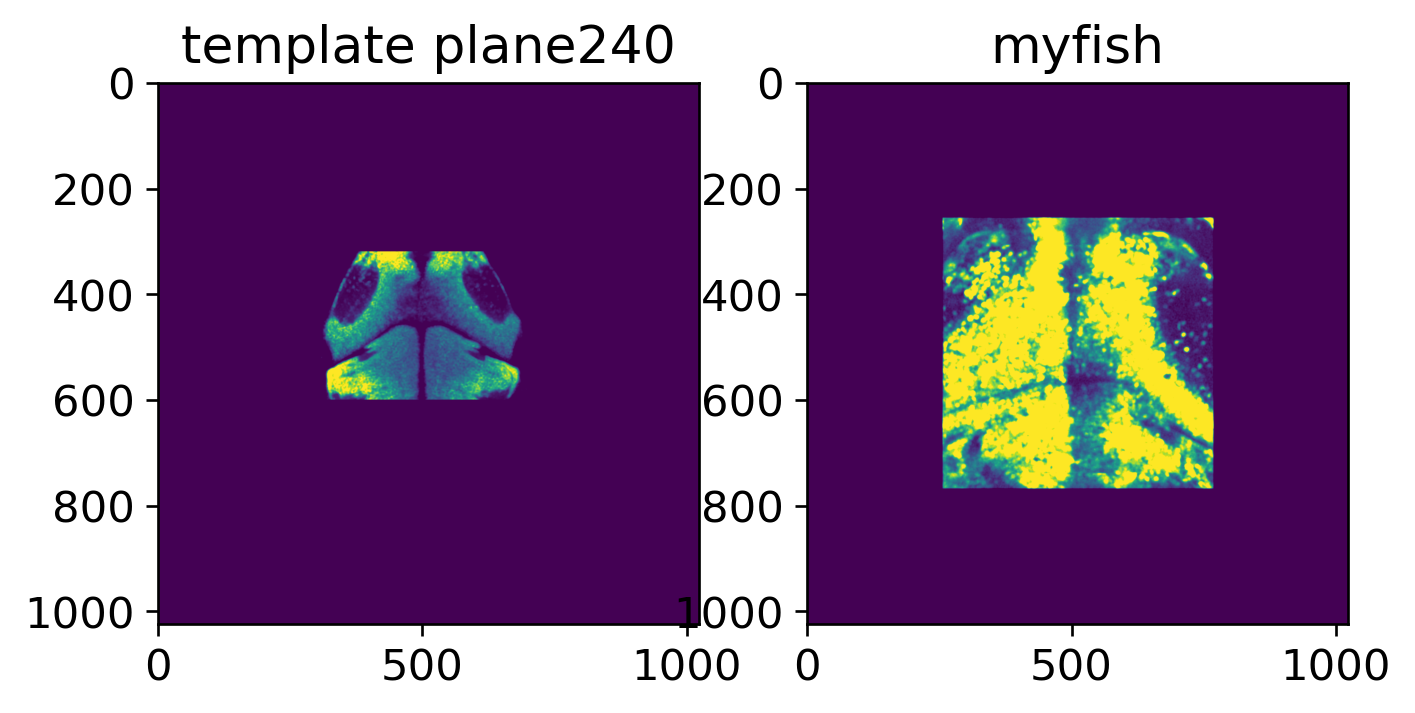

In [38]:
first_register_plane = 0
y_low_cutoff =600
y_top_cutoff =320

template_plane = 240#dorsal:359, ventral:0
template_cut = template_new.copy()
template_cut[:, :y_top_cutoff] =0
template_cut[:, y_low_cutoff:] =0
# downsample (FAST: slicing, no copy until needed)
fig, ax = plt.subplots(1, 2, dpi = 240)
ax[0].imshow(template_cut[template_plane], vmin = vmin_template, vmax = vmax_template)# show a random template plane
ax[0].set_title(f'template plane{template_plane}')
ax[1].imshow(imgs[first_register_plane], vmin = vmin, vmax = vmax)
ax[1].set_title('myfish')
plt.show()
plt.close()

__STEP1B: USE PLANE0 AS REFERENCE, TRANSFORM AND ALIGN TO A SEMI-GOOD PRELIMINARY ATLAS PLANE OF CHOICE__

In [39]:
#two step registration
scalePanalty = 10
iterations_0 = (512, 512)
iterations_1 = (100, 10)
registered_img = sitkalignment.register_image2(
            np.clip(template_cut[template_plane], vmin_template, vmax_template), imgs[first_register_plane], plane_paths[first_register_plane] + '//Alignment//',
            scalePenalty=scalePanalty, iterations=iterations_0, mama_iterations_n=0)

registered_img = sitkalignment.register_image2(
            np.clip(template_cut[template_plane], vmin_template, vmax_template), registered_img, plane_paths[first_register_plane] + '//Alignment//',
            scalePenalty=scalePanalty, iterations=iterations_1, mama_iterations_n=1)

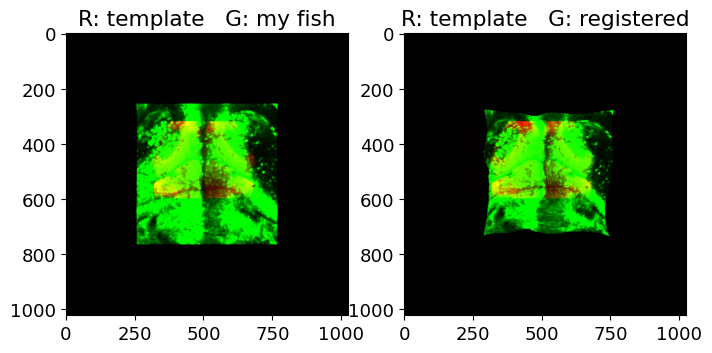

In [40]:
#checking transformation result
fig, ax = plt.subplots(1, 2, figsize = (8, 8))

overlay1 = utils.give_overlay_img(template_cut[template_plane], imgs[first_register_plane])
ax[0].imshow(overlay1)
ax[0].set_title('R: template   G: my fish')
overlay = utils.give_overlay_img(template_cut[template_plane], np.clip(registered_img, vmin, vmax))
ax[1].imshow(overlay)
ax[1].set_title('R: template   G: registered')
plt.show()
plt.close()

__STEP2: USE THE TRANSFORMED IMAGE, FIND BEST ALIGNMENT FOR ALL THE PLANES__

looking at first registered 0, compared to all template planes


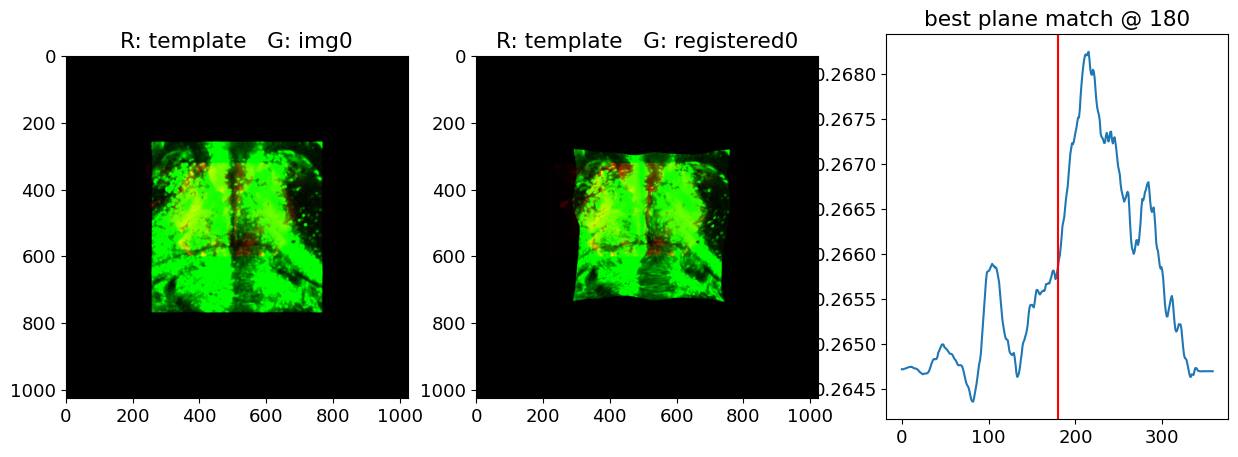

looking at 1, compared to template plane at 173 with range 20um


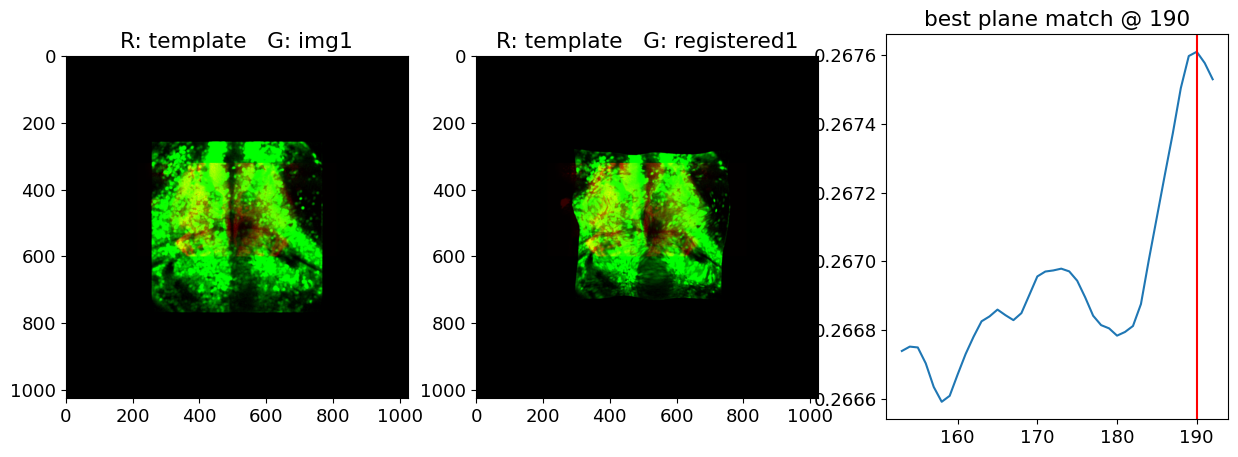

looking at 2, compared to template plane at 166 with range 20um


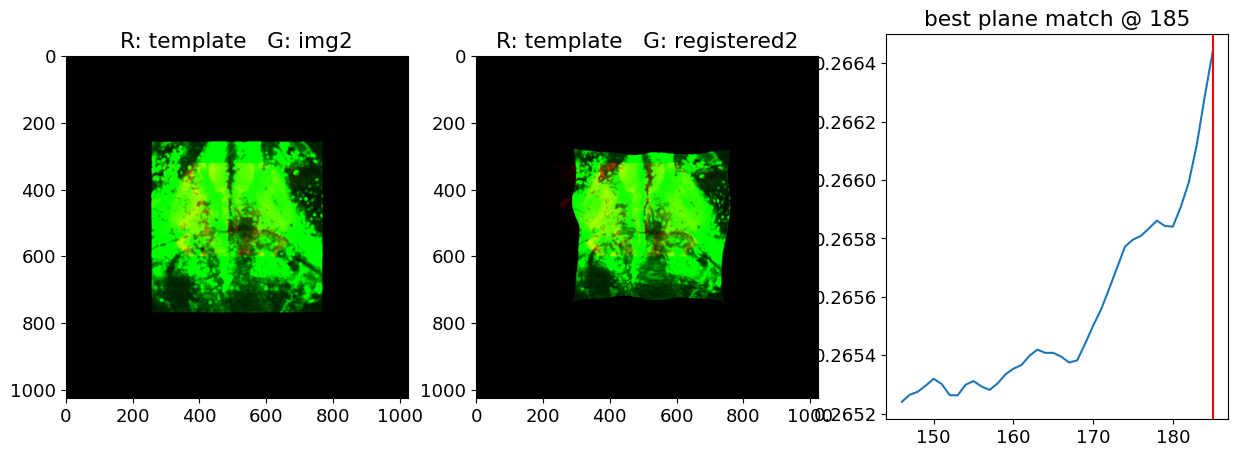

In [41]:
from skimage.metrics import structural_similarity as ssim
best_zs = {plane: None for plane in range(len(plane_paths))}
step =7
zrange = 20
#sort planepaths so it always go to the registered plane first
plane_paths = sorted(plane_paths, key=lambda x: f"plane_{first_register_plane}" not in x)
#use the samething to transform next frames
for plane_path in plane_paths:
    plane = int(str(plane_path).split('plane_')[1])
    if plane == first_register_plane: #look at all planes
        zs = np.arange(0, template_cut.shape[0])
        print(f'looking at first registered {plane}, compared to all template planes')
    else:
        z_center = best_zs[first_register_plane] - step * (int(plane) - first_register_plane)#from the best z match for the first registered plane
        zs = np.arange(z_center - zrange, z_center + zrange)
        print(f'looking at {plane}, compared to template plane at {z_center} with range {zrange}um')

    #grab the mean image of the fish
    img = imgs[plane]
    #do the transform
    new_plane_sitk = sitk.GetImageFromArray(img.astype(np.float32))

    # load saved parameter maps
    transform_files = [
            "transform_pmap_0_0.txt",  # affine
            "transform_pmap_0_1.txt",   # BSpline
            "transform_pmap_1_0.txt",  # affine
            "transform_pmap_1_1.txt" ]  # BSpline
    transform_files = [plane_paths[first_register_plane] + '//Alignment//' + f for f in transform_files]# still reading plane0 things

    # Create Transformix filter
    transformix = sitk.TransformixImageFilter()
    transformix.SetMovingImage(new_plane_sitk)
    transformix.SetTransformParameterMap([sitk.ReadParameterFile(f) for f in transform_files])
    transformix.Execute()
    # get transformed image
    registered_image = sitk.GetArrayFromImage(transformix.GetResultImage())

    #iterate across planes
    similarity_scores = []
    for z in zs:
        score = ssim(np.clip(template_cut[z], vmin_template, vmax_template), registered_image, data_range = 255)
        similarity_scores.append(score)

    fig, ax = plt.subplots(1, 3, figsize = (15, 5))

    best_z = zs[np.argmax(similarity_scores)]
    if plane == first_register_plane:
        best_z = 180
    overlay = utils.give_overlay_img(template_cut[best_z], img)
    ax[0].imshow(overlay)
    ax[0].set_title(f'R: template   G: img{plane}')
    overlay = utils.give_overlay_img(template_cut[best_z], np.clip(registered_image, vmin, vmax))
    ax[1].imshow(overlay)
    ax[1].set_title(f'R: template   G: registered{plane}')
    ax[2].plot(zs, similarity_scores)
    best_zs[plane] = best_z
    ax[2].axvline(best_z, c = 'red')
    ax[2].set_title(f"best plane match @ {best_z}")
    plt.savefig(plane_path + '//Alignment//transformed_result_0.png')
    plt.show()
    plt.close()

#checkmark for tracing which option I used for the final position transformation
step4 = 'X'

__STEP4A: IF PLANE 0 PARAMS DOES LOOK GOOD, SAVE THE SAME PARAMS FOR ALL THE PLANES__


In [42]:
import shutil

for plane_path in plane_paths:
    if 'plane_' + str(first_register_plane) in plane_path:
        plane_firstregister_path = plane_path + '//Alignment//'
    if 'plane_' + str(first_register_plane) not in plane_path:
        plane = plane_path.split('plane_')[1]
        print(f'saving plane {first_register_plane} parmas into plane{plane}')
        # load saved parameter maps
        transform_files = [
            "transform_pmap_0_0.txt",  # affine
            "transform_pmap_0_1.txt",   # BSpline
            "transform_pmap_1_0.txt",  # affine
            "transform_pmap_1_1.txt" ]  # BSpline
        transform_files = [plane_firstregister_path + '//' + f for f in transform_files]# still reading plane0 things
        for f in transform_files:
            shutil.copy(f, plane_path + '//Alignment//')
step4 = 'A'

saving plane 0 parmas into plane1
saving plane 0 parmas into plane2


__STEP4B: IF PLANE 0 PARAMS DOESN'T LOOK GOOD, RE-TRANSFORM THE PLANE0 TO MATCH THE BETTER TEMPLATE AT PLANE Z__

looking at 0


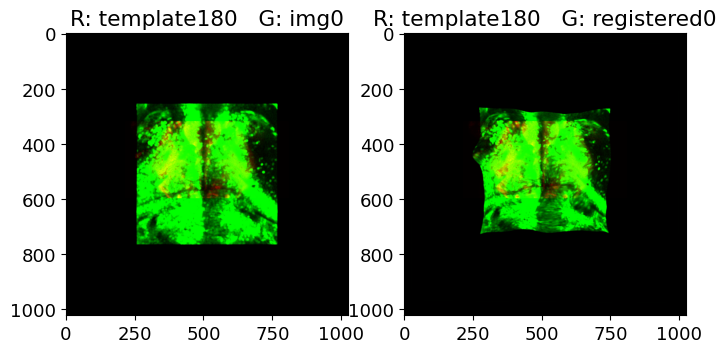

looking at 1


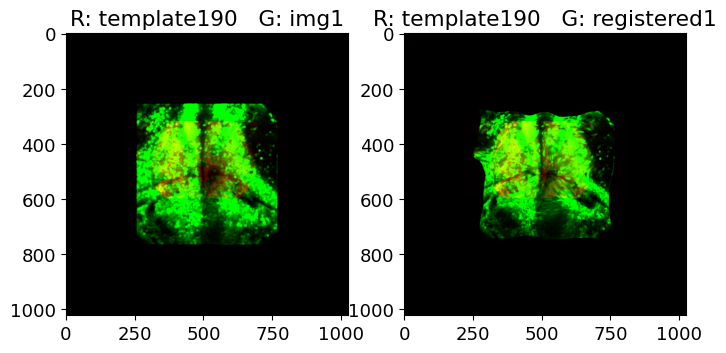

looking at 2


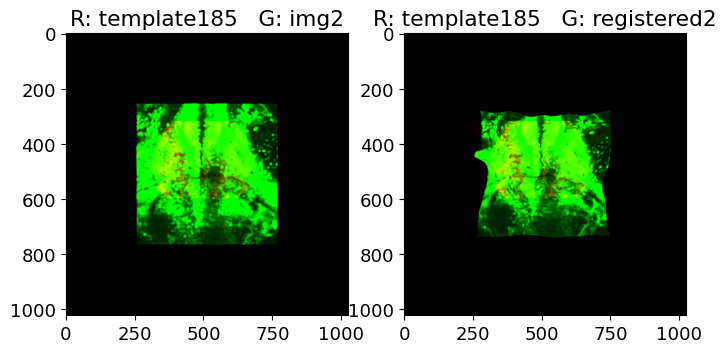

In [43]:
for plane_path in plane_paths:
    plane = int(plane_path.split('plane_')[1])
    print(f'looking at {plane}')

    #grab the mean image of the fish
    img = imgs[plane]
    #do the transform
    new_plane_sitk = sitk.GetImageFromArray(img.astype(np.float32))

    planeout_path = plane_path + '//Alignment//'

    #two step registration
    registered_img = sitkalignment.register_image2(
            np.clip(template_cut[best_zs[plane]], vmin_template, vmax_template), img, planeout_path,
            scalePenalty=scalePanalty,iterations=iterations_0, mama_iterations_n=0)

    registered_img = sitkalignment.register_image2(
            np.clip(template_cut[best_zs[plane]], vmin_template, vmax_template), registered_img, planeout_path,
            scalePenalty=scalePanalty, iterations=iterations_1, mama_iterations_n=1)

    #checking transformation result
    fig, ax = plt.subplots(1, 2, figsize=(8, 8))
    overlay = utils.give_overlay_img(template_cut[best_zs[plane]], img)
    ax[0].imshow(overlay)
    ax[0].set_title(f'R: template{best_zs[plane]}   G: img{plane}')
    overlay = utils.give_overlay_img(template_cut[best_zs[plane]], np.clip(registered_img, vmin, vmax))
    ax[1].imshow(overlay)
    ax[1].set_title(f'R: template{best_zs[plane]}   G: registered{plane}')
    plt.savefig(f'{plane_path}//Alignment//transformed_result_1.png')
    plt.show()
    plt.close()
step4 = 'B'

__STEP 5: TRANSFORM ALL POINT POSITIONS__

looking at 0


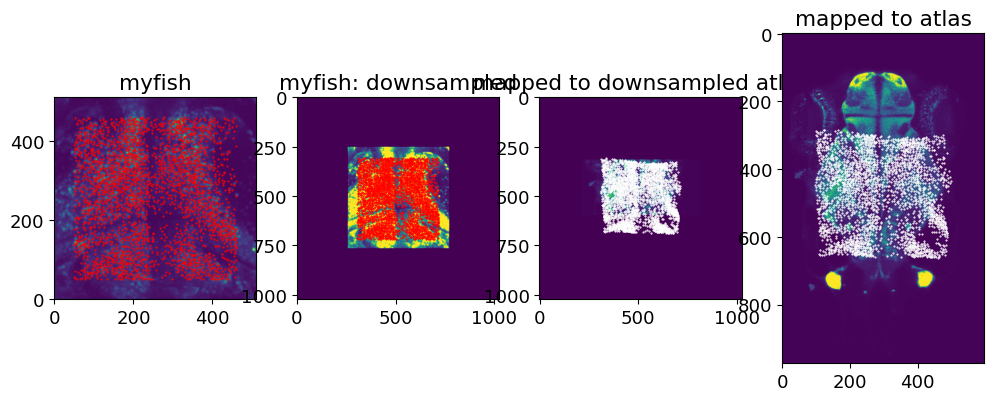

looking at 1


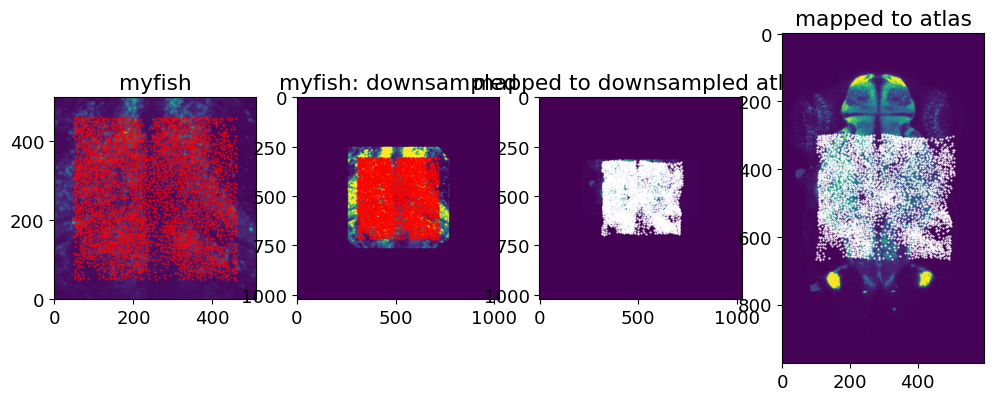

looking at 2


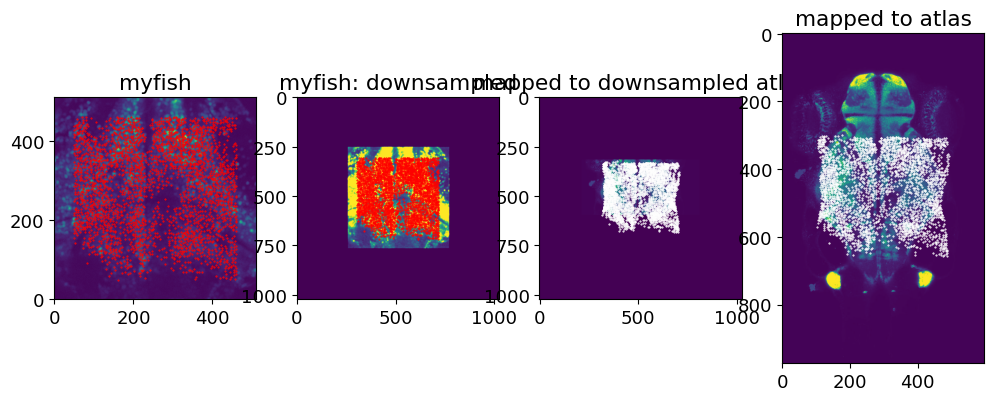

In [44]:
#Create atlas point array
x = np.arange(imgsize)
y = np.arange(imgsize)
xx, yy = np.meshgrid(x, y)  # shape: (imgsize, imgsize)
atlas_points = np.column_stack([xx.ravel(), yy.ravel()])

for plane_path in plane_paths:
    plane = int(plane_path.split('plane_')[1])
    print(f'looking at {plane}')

    #grab the mean image of the fish
    ops = np.load(plane_path + '//ops.npy', allow_pickle=True)
    myfish_img = ops.item()['refImg']
    img = imgs[plane]#this is post transformed images!
    #do the transform
    new_plane_sitk = sitk.GetImageFromArray(img.astype(np.float32))

    #map all atlas points on to this transformed image
    atlas_points_transformed = utils.transform_points_with_transformix(atlas_points, plane_path + '//Alignment', img)#coords in og imag

    #get all neurons location in the untransformed images
    myfish_points = utils.read_cellpos(plane_path + '//', plane)
    #because of down sampling, need to match the og position to the downsampled og position
    down_myfish_points = utils.downsample_points(myfish_points, orig_shape = myfish_img.shape, imgsize = imgsize, downsample = downsample, rot = -rot)
    #for each neuron, find the closest transformed atlas point in the transformed space
    point_mapping_index= [np.argmin(np.add(np.square(np.subtract(point.xpos, atlas_points_transformed[:, 0])),
                                         np.square(np.subtract(point.ypos, atlas_points_transformed[:, 1]))))
                              for _, point in down_myfish_points.iterrows()]
    atlas_myfish_points = atlas_points[point_mapping_index]
    #upsampling the mapped atlas point locations
    atlas_myfish_points_up = pd.DataFrame(atlas_myfish_points, columns = ['xpos', 'ypos'])
    atlas_myfish_points_up = utils.upsample_points(atlas_myfish_points_up, orig_shape = template[best_zs[plane]].shape, imgsize = imgsize, downsample = downsample)
    #assign z locations
    atlas_myfish_points_up.loc[:, 'zpos'] = plane
    atlas_myfish_points_up.loc[:, 'zpos_atlas'] = best_zs[plane]

    #find the correct regions
    atlas_myfish_points_up = utils.return_point_regions(atlas_myfish_points_up, best_zs)
    atlas_myfish_points_up.to_csv(plane_path + '//Alignment//new_pos.csv', index = False)

    #check it out
    fig, ax = plt.subplots(1, 4, figsize = (12, 5))
    #og
    ax[0].imshow(np.rot90(np.flipud(myfish_img), k = -1), origin = 'lower')
    ax[0].scatter(myfish_points.xpos, myfish_points.ypos, marker='.', s = 1, color = 'red')
    ax[0].set_title('myfish')
    #pretransformation
    ax[1].imshow(img)
    ax[1].scatter(down_myfish_points.xpos, down_myfish_points.ypos, marker='.', s = 1, color = 'red')
    ax[1].set_title('myfish: downsampled')
    #post transformation
    ax[2].imshow(template_cut[best_zs[plane]])
    ax[2].scatter(atlas_myfish_points[:, 0], atlas_myfish_points[:, 1], marker='.', s = 1, color = 'white')
    ax[2].set_title('mapped to downsampled atlas')
    #post transformation, upsample back
    ax[3].imshow(template[best_zs[plane]])
    ax[3].scatter(atlas_myfish_points_up.xpos, atlas_myfish_points_up.ypos, marker='.', s = 1, color = 'white')
    ax[3].set_title('mapped to atlas')

    plt.savefig(f'{plane_path}//Alignment//new_pos.png')
    plt.show()
    plt.close()

In [45]:
import json
for plane_path in plane_paths:
    params = {'rot': rot, 'vmin': vmin, 'vmax': vmax, 'vmin_template': vmin_template, 'vmax_template': vmax_template, 'y_top_cutoff':y_top_cutoff, 'y_low_cutoff': y_low_cutoff, 'downsample': downsample, 'gaussian_sigma': gaussian_sigma, 'template_path': template_path, 'scalePanalty': scalePanalty, 'iterations_0': iterations_0, 'iterations_1': iterations_1, 'new_pos_reference': step4}
    with open(plane_path + "//Alignment//params.txt", "w") as f:
        json.dump(params, f, indent=4)